<a href="https://colab.research.google.com/github/Kunalthakur01/3D-carousel/blob/main/SmartCart_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [6]:
#data preprocessing
#1) remove missing values
df['Income'] = df["Income"].fillna(df['Income'].median())

In [7]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [8]:
#feature engineering

df["Age"] = 2026-df["Year_Birth"]

In [9]:
#Customer Joining Date
df['Dt_Customer'] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)

Reference_date =df["Dt_Customer"].max()
df["customer_tenure_days"] = (Reference_date-df['Dt_Customer']).dt.days

In [10]:
#spending
df['Total_spending'] = df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [11]:
#children
df["Total_Childern"] = df["Kidhome"]+df["Teenhome"]

In [12]:
#Education
df['Education'].value_counts()

df["Education"]=df["Education"].replace({
    "Basic":"undergraduate",
    "2n Cycle":"undergraduate",
    "Graduation":"graduate",
    "Master":"postgraduate",
    "PhD":"postgraduate"

})



In [13]:
#Marital Status
df['Living_with'] = df['Marital_Status'].replace({
    "Married":"Partner","Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "widow":"Alone","Absurd":"Alone"
})

In [14]:
#Marital Status
df['Living_with'].value_counts()

,count
Living_with,
Partner,1444
Alone,717
Widow,77
YOLO,2


In [15]:
#drop columns
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop = cols+spending_cols
df_clean = df.drop(columns=cols_to_drop)

In [16]:
df_clean.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Total_spending,Total_Childern,Living_with
0,graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


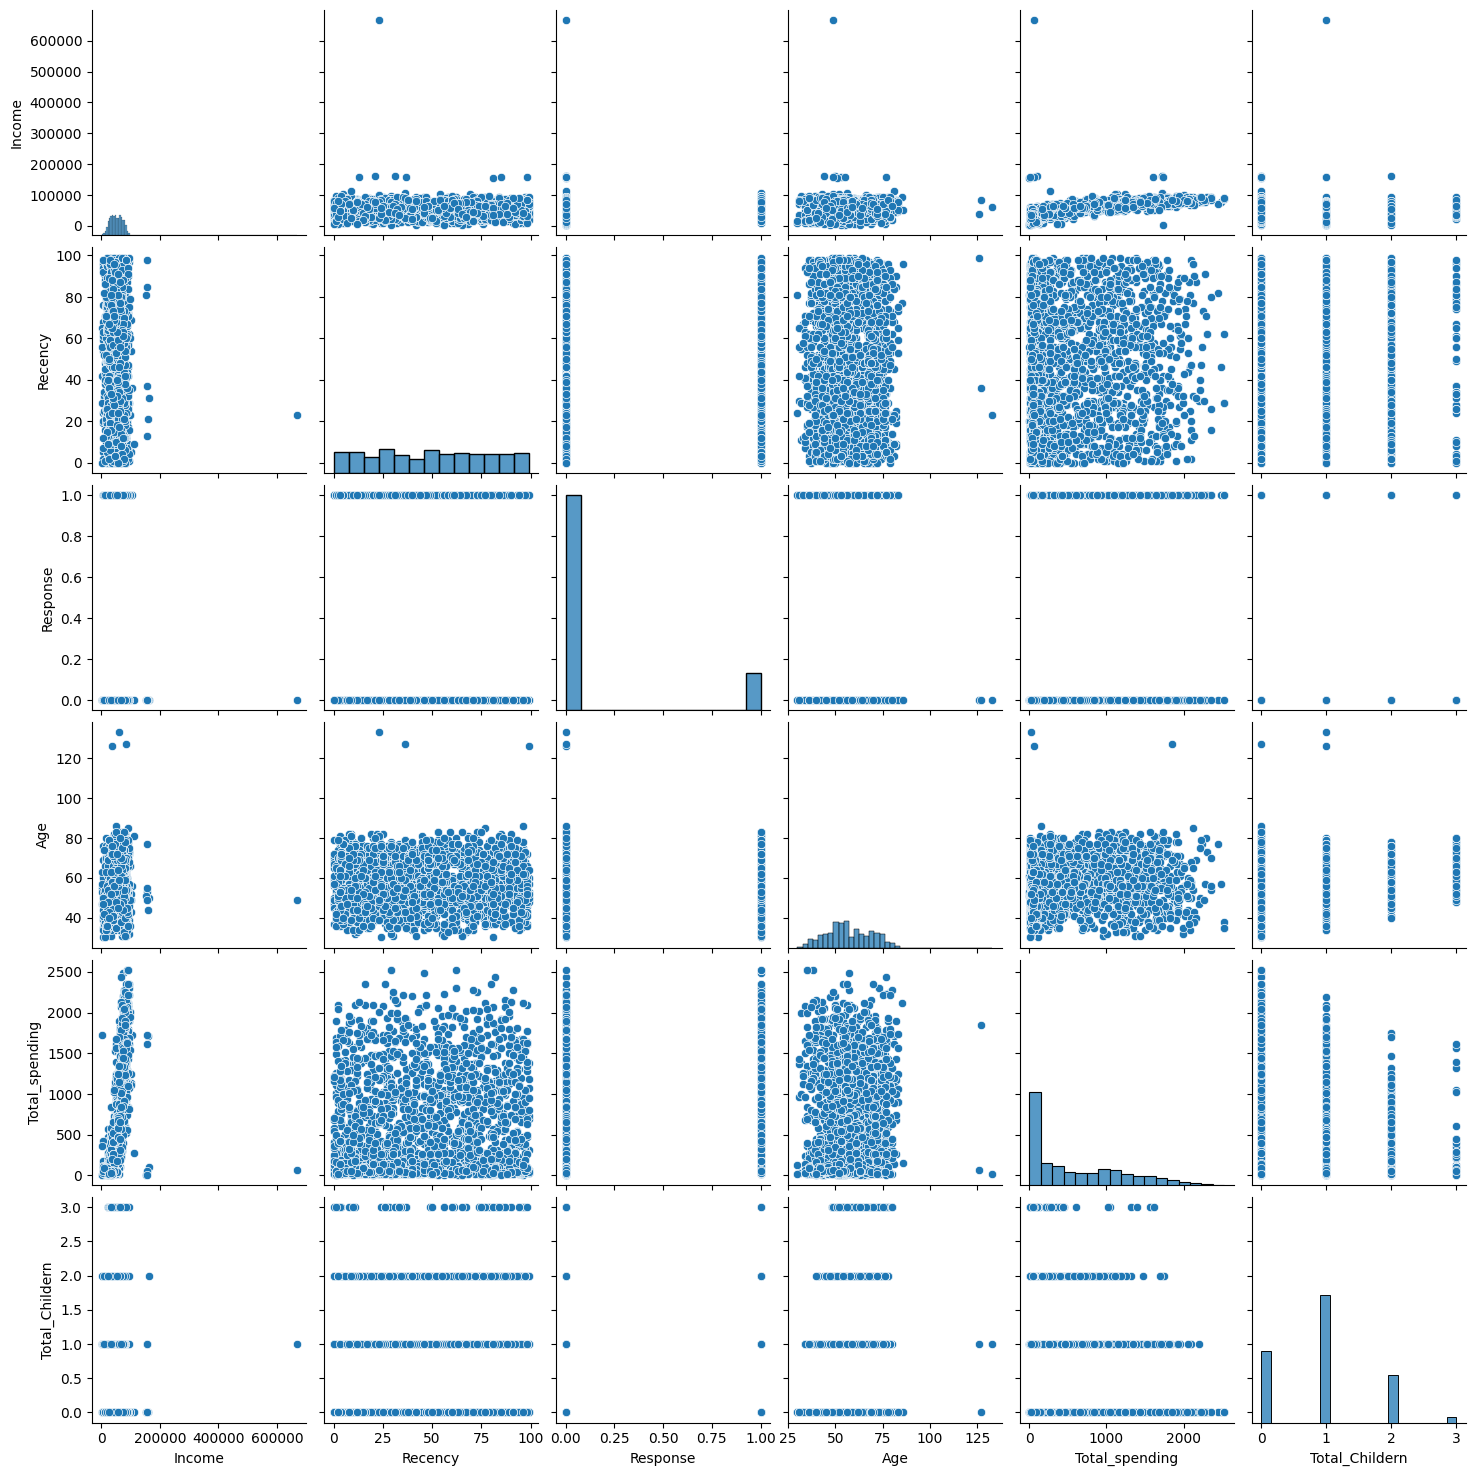

In [17]:
#outliners
cols = ["Income","Recency","Response","Age","Total_spending","Total_Childern"]

#relative plots of some fetures- pair plots
sns.pairplot(df_clean[cols])

In [18]:
#remove the outliers
print("data size with outliers : ", len(df_clean))
df_clean = df_clean[(df_clean["Age"]<90)]
df_clean = df_clean[(df_clean["Income"]<600_000)]

print("data size with outliers : ", len(df_clean))

data size with outliers :  2240
data size with outliers :  2236


<Axes: >

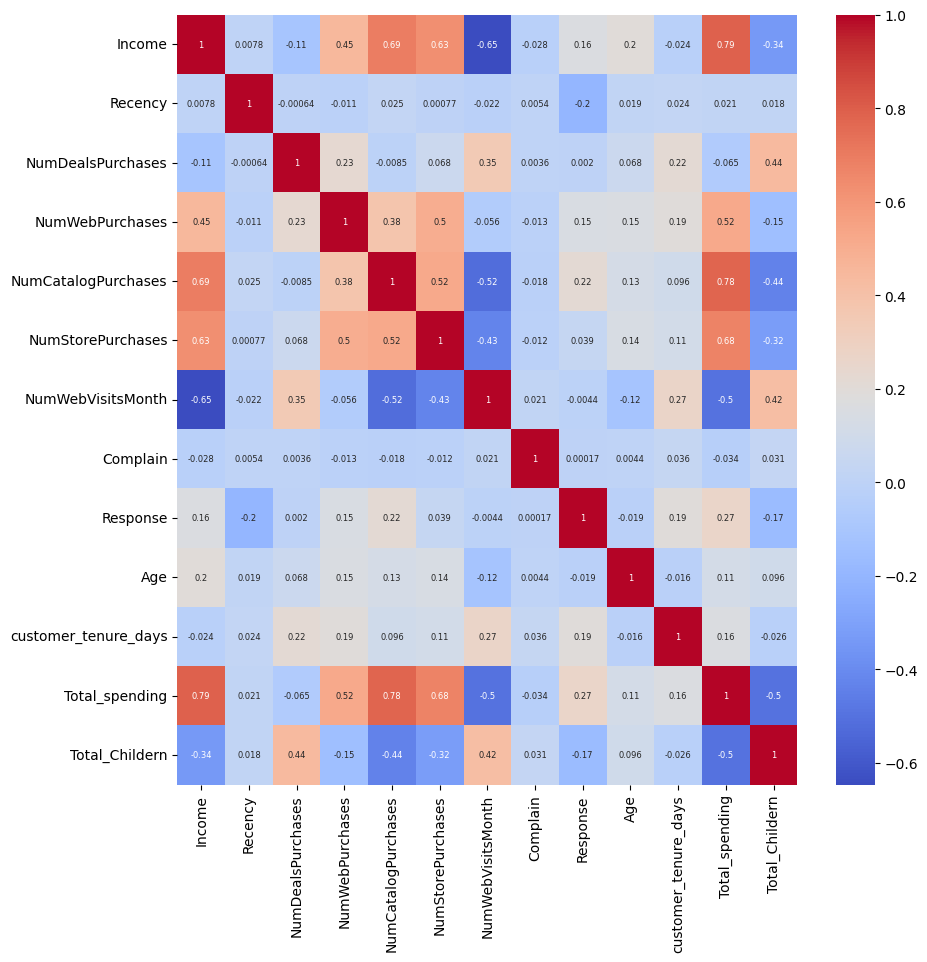

In [19]:
#heat map
corr = df_clean.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(
    corr,
    annot = True,
    annot_kws={"size":6},
    cmap = "coolwarm"
)


In [20]:
#feature encoding
from sklearn.preprocessing import OneHotEncoder

In [21]:
ohe = OneHotEncoder()
cat_cols = ['Education','Living_with']
enc_cols = ohe.fit_transform(df_clean[cat_cols])

In [22]:

enc_df = pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_clean.index)

In [23]:
df_clean.shape

(2236, 15)

In [24]:
df_clean.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Total_spending,Total_Childern,Living_with
0,graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [25]:
df_encoded = pd.concat([df_clean.drop(columns=cat_cols),enc_df],axis=1)

In [26]:
df_encoded.shape

(2236, 20)

In [27]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Total_spending,Total_Childern,Education_graduate,Education_postgraduate,Education_undergraduate,Living_with_Alone,Living_with_Partner,Living_with_Widow,Living_with_YOLO
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [28]:
#scaling
from sklearn.preprocessing import StandardScaler


In [29]:
X = df_encoded

In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [31]:
#visualize
X_scaled.shape

(2236, 20)

In [32]:
#2D
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3d projection')

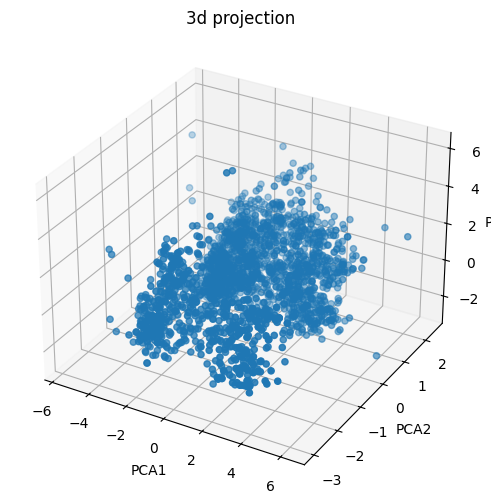

In [33]:
# plot
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

In [34]:
pca.explained_variance_ratio_

array([0.20864879, 0.09966859, 0.0941374 ])